### 🎓 Student Dropout Prediction
#### Objective
Build machine learning models to predict student outcomes:
- Graduate
- Dropout
- Enrolled
#### Experiments
We compare two scenarios:
- Enrollment-only features
  → Can we predict dropout risk at the time of enrollment?
- Enrollment + First Semester features
  → How much does academic performance improve predictions?
#### Tools
- Databricks
- Delta Tables
- Pandas
- Scikit-learn
- MLflow (experiment tracking)

In [0]:
spark_df = spark.table("workspace.default.student_dropout_raw")
df = spark_df.toPandas()
for col in df.select_dtypes(include=["int64", "int32"]).columns:
    df[col] = df[col].astype(float)
df.head()

,marital_status,application_mode,application_order,course,daytime_evening_attendance,previous_qualification,previous_qualification_grade,nacionality,mothers_qualification,fathers_qualification,mothers_occupation,fathers_occupation,admission_grade,displaced,educational_special_needs,debtor,tuition_fees_up_to_date,gender,scholarship_holder,age_at_enrollment,international,curricular_units_1st_sem_credited,curricular_units_1st_sem_enrolled,curricular_units_1st_sem_evaluations,curricular_units_1st_sem_approved,curricular_units_1st_sem_grade,curricular_units_1st_sem_without_evaluations,curricular_units_2nd_sem_credited,curricular_units_2nd_sem_enrolled,curricular_units_2nd_sem_evaluations,curricular_units_2nd_sem_approved,curricular_units_2nd_sem_grade,curricular_units_2nd_sem_without_evaluations,unemployment_rate,inflation_rate,gdp,target
0,1.0,17.0,5.0,9500.0,1.0,1.0,124.0,1.0,3.0,38.0,2.0,1.0,119.8,0.0,0.0,0.0,1.0,1.0,0.0,19.0,0.0,0.0,8.0,11.0,7.0,13.867143,0.0,0.0,8.0,11.0,7.0,13.867143,0.0,10.8,1.4,1.74,Graduate
1,1.0,39.0,1.0,9500.0,1.0,1.0,114.0,1.0,37.0,37.0,9.0,9.0,130.0,0.0,0.0,0.0,1.0,1.0,0.0,25.0,0.0,0.0,8.0,11.0,6.0,12.675000,0.0,0.0,8.0,11.0,6.0,12.675000,0.0,12.7,3.7,-1.70,Graduate
2,1.0,16.0,1.0,171.0,1.0,1.0,155.0,1.0,1.0,3.0,5.0,10.0,167.3,1.0,0.0,0.0,1.0,1.0,0.0,19.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,13.9,-0.3,0.79,Graduate
3,1.0,17.0,2.0,9853.0,1.0,1.0,114.0,1.0,1.0,19.0,9.0,9.0,111.9,1.0,0.0,0.0,1.0,1.0,1.0,20.0,0.0,0.0,6.0,6.0,6.0,12.000000,0.0,0.0,6.0,7.0,6.0,12.500000,0.0,7.6,2.6,0.32,Enrolled
4,1.0,1.0,1.0,171.0,1.0,1.0,133.1,1.0,38.0,37.0,5.0,5.0,136.0,1.0,0.0,0.0,1.0,1.0,0.0,22.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,12.7,3.7,-1.70,Dropout


In [0]:
numeric_cols = [
    "previous_qualification_grade",
    "admission_grade",
    "age_at_enrollment",
    "curricular_units_1st_sem_grade",
    "curricular_units_2nd_sem_grade",
    "unemployment_rate",
    "inflation_rate",
    "gdp",
]

# Convert all numeric columns to float64 to avoid MLflow warnings
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].astype(float)

#### 📊Feature Set Definitions
We define two different feature sets to simulate different prediction timepoints:
- Enrollment-only features: Available at admission time.
- First semester features: Includes academic performance from semester 1.

This allows us to measure how predictive power changes over time.

In [0]:
enrollment_only_cols = [
    col for col in df.columns 
    if not col.startswith("curricular_units_1st_sem")
    and not col.startswith("curricular_units_2nd_sem")
    and col != "target"
]

first_sem_cols = [
    col for col in df.columns
    if not col.startswith("curricular_units_2nd_sem")
    and col != "target"
]

#### 🎯 Target Encoding

The target variable (Graduate, Dropout, Enrolled) is label-encoded into integers for modeling.

In [0]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["target_encoded"] = le.fit_transform(df["target"])

In [0]:
dict(zip(le.classes_, le.transform(le.classes_)))

{'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}

#### 🔀 Train/Test Split

We use a stratified 80/20 split to preserve class distribution across training and testing sets.

In [0]:
from sklearn.model_selection import train_test_split

X1 = df[enrollment_only_cols]
X2 = df[first_sem_cols]
y = df["target_encoded"]

X1_train, X1_test, y_train, y_test = train_test_split(
    X1, y, test_size=0.2, stratify=y, random_state=42
)

X2_train, X2_test, _, _ = train_test_split(
    X2, y, test_size=0.2, stratify=y, random_state=42
)

#### 🧩 Feature Typing

We separate:
- Numerical features → StandardScaler
- Categorical features → OneHotEncoder

This preprocessing will be handled inside a Scikit-learn Pipeline to prevent data leakage.

In [0]:
numeric_cols = [
    "previous_qualification_grade",
    "admission_grade",
    "age_at_enrollment",
    "curricular_units_1st_sem_grade",
    "curricular_units_2nd_sem_grade",
    "unemployment_rate",
    "inflation_rate",
    "gdp",
]

INFO:py4j.clientserver:Received command c on object id p0


In [0]:
all_features = [col for col in df.columns if col not in ["target", "target_encoded"]]

categorical_cols = [col for col in all_features if col not in numeric_cols]

In [0]:
# For X1 (Enrollment-only features)
numeric_cols_X1 = [c for c in numeric_cols if c in X1_train.columns]
categorical_cols_X1 = [c for c in categorical_cols if c in X1_train.columns]

# For X2 (Enrollment + 1st sem features)
numeric_cols_X2 = [c for c in numeric_cols if c in X2_train.columns]
categorical_cols_X2 = [c for c in categorical_cols if c in X2_train.columns]

INFO:py4j.clientserver:Received command c on object id p0


In [0]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

#### 📈 Experiment Tracking with MLflow

All models are logged to MLflow, including:
- Model parameters
- Accuracy
- Macro F1 score
- Full pipeline (preprocessing + model)
- Registered model version
This ensures reproducibility and experiment comparison.

In [0]:
import mlflow

mlflow.set_experiment("/Shared/student_dropout_prediction")

<Experiment: artifact_location='dbfs:/databricks/mlflow-tracking/3110738517659667', creation_time=1772364159438, experiment_id='3110738517659667', last_update_time=1774292295094, lifecycle_stage='active', name='/Shared/student_dropout_prediction', tags={'mlflow.experiment.sourceName': '/Shared/student_dropout_prediction',
 'mlflow.experimentKind': 'custom_model_development',
 'mlflow.experimentType': 'MLFLOW_EXPERIMENT',
 'mlflow.ownerEmail': 'jmopjordsmoen@gmail.com',
 'mlflow.ownerId': '74238314197831'}>

In [0]:
mlflow.sklearn.autolog()

In [0]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

def make_pipeline(numeric_cols, categorical_cols, model_type="logistic"):
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ]
    )
    
    if model_type=="logistic":
        classifier = LogisticRegression(max_iter=1000, class_weight="balanced")
    else:
        classifier = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
    
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", classifier)])
    return pipeline

# Pipelines for X1
log_pipeline_X1 = make_pipeline(numeric_cols_X1, categorical_cols_X1, "logistic")
rf_pipeline_X1 = make_pipeline(numeric_cols_X1, categorical_cols_X1, "rf")

# Pipelines for X2
log_pipeline_X2 = make_pipeline(numeric_cols_X2, categorical_cols_X2, "logistic")
rf_pipeline_X2 = make_pipeline(numeric_cols_X2, categorical_cols_X2, "rf")

In [0]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

def train_and_log(model_pipeline, model_name, X_train, X_test, y_train, y_test, feature_set):
    with mlflow.start_run(run_name=model_name):
        model_pipeline.fit(X_train, y_train)
        preds = model_pipeline.predict(X_test)
        
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average="macro")
        
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("feature_set", feature_set)
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("macro_f1", f1)
        
        mlflow.set_tag("problem_type", "multiclass_classification")
        mlflow.set_tag("class_imbalance", "true")
        
        mlflow.sklearn.log_model(
            model_pipeline,
            "model",
            registered_model_name=f"StudentDropout_{model_name}",
            input_example=X_train.head(3)
        )
        
        print(f"{model_name} Accuracy:", acc)
        print(f"{model_name} Macro F1:", f1)
        print("\nClassification Report:\n")
        print(classification_report(y_test, preds))
        
        return {"model": model_name, "feature_set": feature_set, "accuracy": acc, "macro_f1": f1}


####🧪 Model Experiments

We train four models:

#####Enrollment-only Feature Set
- Logistic Regression
- Random Forest

#####Enrollment + First Semester Feature Set
- Logistic Regression
- Random Forest

In [0]:
results = []
# Model 1: Enrollment only
results.append(
    train_and_log(log_pipeline_X1, "Logistic_Enrollment",
                  X1_train, X1_test, y_train, y_test, "Enrollment")
)

results.append(
    train_and_log(rf_pipeline_X1, "RandomForest_Enrollment",
                  X1_train, X1_test, y_train, y_test, "Enrollment")
)
# Model 2: Enrollment + 1st semester
results.append(
    train_and_log(log_pipeline_X2, "Logistic_FirstSemester",
                  X2_train, X2_test, y_train, y_test, "FirstSemester")
)

results.append(
    train_and_log(rf_pipeline_X2, "RandomForest_FirstSemester",
                  X2_train, X2_test, y_train, y_test, "FirstSemester")
)

INFO:py4j.clientserver:Received command c on object id p0
/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Registered model 'StudentDropout_Logistic_Enrollment' already exists. Creating a new version of this model...
Created version '10' of model 'workspace.default.studentdropout_logistic

Logistic_Enrollment Accuracy: 0.5898305084745763
Logistic_Enrollment Macro F1: 0.5536620587769243

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.61      0.63       284
           1       0.28      0.44      0.34       159
           2       0.74      0.63      0.68       442

    accuracy                           0.59       885
   macro avg       0.56      0.56      0.55       885
weighted avg       0.63      0.59      0.61       885



/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Registered model 'StudentDropout_RandomForest_Enrollment' already exists. Creating a new version of this model...
Created version '10' of model 'workspace.default.studentdropout_randomforest_enrollment'.


RandomForest_Enrollment Accuracy: 0.6632768361581921
RandomForest_Enrollment Macro F1: 0.5306821590991099

Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.63      0.66       284
           1       0.37      0.11      0.17       159
           2       0.67      0.88      0.76       442

    accuracy                           0.66       885
   macro avg       0.58      0.54      0.53       885
weighted avg       0.63      0.66      0.62       885



/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Registered model 'StudentDropout_Logistic_FirstSemester' already exists. Creating a new version of this model...
Created version '10' of model 'workspace.default.studentdropout_logistic_firstsemester'.


Logistic_FirstSemester Accuracy: 0.7141242937853107
Logistic_FirstSemester Macro F1: 0.6724712766338423

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.74      0.75       284
           1       0.39      0.55      0.46       159
           2       0.87      0.76      0.81       442

    accuracy                           0.71       885
   macro avg       0.67      0.68      0.67       885
weighted avg       0.75      0.71      0.73       885



/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Registered model 'StudentDropout_RandomForest_FirstSemester' already exists. Creating a new version of this model...


RandomForest_FirstSemester Accuracy: 0.7446327683615819
RandomForest_FirstSemester Macro F1: 0.6354636501592403

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.77      0.76       284
           1       0.51      0.22      0.31       159
           2       0.77      0.92      0.84       442

    accuracy                           0.74       885
   macro avg       0.68      0.64      0.64       885
weighted avg       0.72      0.74      0.72       885



Created version '10' of model 'workspace.default.studentdropout_randomforest_firstsemester'.


#### 🔧 Hyperparameter Tuning

To improve model performance, we perform hyperparameter tuning using cross-validation.

We focus on the best-performing scenario (First Semester features) and optimize model parameters using GridSearchCV.

All tuning results are tracked in MLflow for comparison with baseline models.

In [0]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
import mlflow
import mlflow.sklearn

# Convert integers to float to avoid MLflow warnings
for col in X2_train.select_dtypes(include=["int64", "int32"]).columns:
    X2_train[col] = X2_train[col].astype(float)
    X2_test[col] = X2_test[col].astype(float)

param_grid = {"classifier__C": [0.01, 0.1, 1, 10]}

grid = GridSearchCV(
    log_pipeline_X2,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=1  # safer if cluster is small
)

with mlflow.start_run(run_name="Logistic_Tuned_FirstSemester"):
    
    grid.fit(X2_train, y_train)
    
    best_model = grid.best_estimator_
    preds = best_model.predict(X2_test)
    
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    
    # Log the model to MLflow
    mlflow.sklearn.log_model(
        best_model,
        "model",
        registered_model_name="StudentDropout_Logistic_Tuned",
        input_example=X2_train.head(3)  # small example to avoid Py4J overload
    )
    
    print("Best Params:", grid.best_params_)
    print("Accuracy:", acc)
    print("Macro F1:", f1)

2026/03/23 19:04:32 INFO mlflow.sklearn.utils: Logging the 5 best runs, no runs will be omitted.
/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Registered model 'StudentDropout_Logistic_Tuned' already exists. Creating a new version of this model...


Best Params: {'classifier__C': 1}
Accuracy: 0.7141242937853107
Macro F1: 0.6724712766338423


Created version '6' of model 'workspace.default.studentdropout_logistic_tuned'.


#### 📈 Learning Curve Analysis

Learning curve to illustrate how model performance evolves as the training dataset size increases.

Helps display:

- Overfitting (large gap between training and validation performance)
- Underfitting (both scores low)
- Whether additional data could improve performance

We evaluate the best-performing model (Logistic Regression with first semester features).

IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
INFO:py4j.clientserver:Error while sending or receiving.
Traceback (most recent call last):
  File "/databricks/spark/python/lib/py4j-0.10.9.9-src.zip/py4j/clientserver.py", line 527, in send_command
    self.socket.sendall(command.encode("utf-8"))
ConnectionResetError: [Errno 104] Connection reset by peer
INFO:py4j.clientserver:Closing down clientserver connection
INFO:root:Exception while sendin

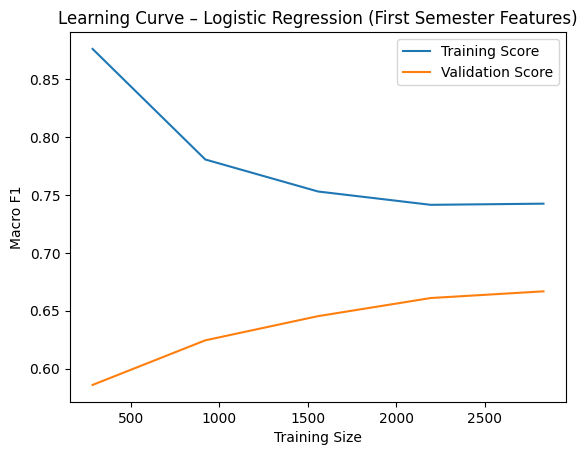

In [0]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    log_pipeline_X2,
    X2_train,
    y_train,
    cv=5,
    scoring="f1_macro",
    n_jobs=2,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")

plt.title("Learning Curve – Logistic Regression (First Semester Features)")
plt.xlabel("Training Size")
plt.ylabel("Macro F1")
plt.legend()
plt.show()

####📊 Results Summary
#####Enrollment-only models
- Moderate predictive performance.
- Dropout recall is limited.
- Early prediction is possible but uncertain.

#####Enrollment + First Semester models

- Significant performance improvement.
- Academic performance strongly influences outcome prediction.

#####Key Insight
Student performance during the first semester provides substantial predictive signal. Early intervention strategies may benefit from monitoring first-semester metrics.

In [0]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(model, X_test, y_test, title):
    
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    
    plt.figure()
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["Dropout", "Enrolled", "Graduate"],
        yticklabels=["Dropout", "Enrolled", "Graduate"]
    )
    
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

####🔎 Class-Level Performance Analysis (Confusion Matrices)
While accuracy and macro F1 provide overall performance metrics, they do not reveal which classes are being misclassified.

Since the primary business objective is identifying students at risk of dropout, it is important to evaluate:
- How well the model detects Dropout cases (recall)
- Whether the model confuses Enrolled and Dropout
- Whether predictions are biased toward the majority class (Graduate)

The confusion matrices below allow us to inspect class-level behavior and identify potential weaknesses in the models.

INFO:py4j.clientserver:Error while sending or receiving.
Traceback (most recent call last):
  File "/databricks/spark/python/lib/py4j-0.10.9.9-src.zip/py4j/clientserver.py", line 527, in send_command
    self.socket.sendall(command.encode("utf-8"))
ConnectionResetError: [Errno 104] Connection reset by peer
INFO:py4j.clientserver:Closing down clientserver connection
INFO:root:Exception while sending command.
Traceback (most recent call last):
  File "/databricks/spark/python/lib/py4j-0.10.9.9-src.zip/py4j/clientserver.py", line 527, in send_command
    self.socket.sendall(command.encode("utf-8"))
ConnectionResetError: [Errno 104] Connection reset by peer

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/databricks/spark/python/lib/py4j-0.10.9.9-src.zip/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/spark/py

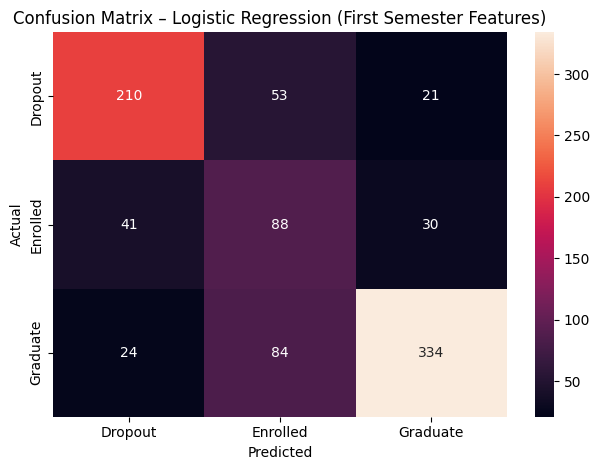

In [0]:
plot_confusion_matrix(
    log_pipeline_X2,
    X2_test,
    y_test,
    "Confusion Matrix – Logistic Regression (First Semester Features)"
)

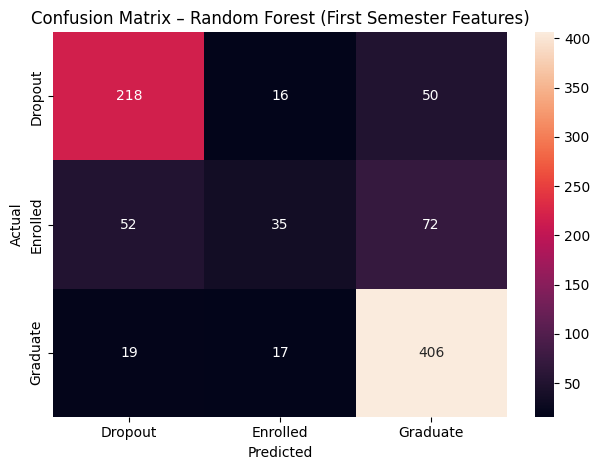

In [0]:
plot_confusion_matrix(
    rf_pipeline_X2,
    X2_test,
    y_test,
    "Confusion Matrix – Random Forest (First Semester Features)"
)

####📊 Interpretation
#####Logistic Regression (First Semester Features)
- More balanced predictions across classes.
- Dropout recall is moderate, meaning some at-risk students are successfully identified.
- Some confusion remains between Enrolled and Dropout.

#####Random Forest (First Semester Features)
- Strong performance on Graduate class.
- Lower recall for Dropout class, indicating difficulty detecting minority cases.
- Tendency to favor the majority class.

#####Key Insight

Although Random Forest achieves slightly higher overall accuracy, Logistic Regression provides more balanced class performance.

For an early-warning intervention system, balanced detection of Dropout cases may be more valuable than maximizing overall accuracy.

In [0]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df

,model,feature_set,accuracy,macro_f1
0,Logistic_Enrollment,Enrollment,0.589831,0.553662
1,RandomForest_Enrollment,Enrollment,0.663277,0.530682
2,Logistic_FirstSemester,FirstSemester,0.714124,0.672471
3,RandomForest_FirstSemester,FirstSemester,0.744633,0.635464


####📊 Model Performance Comparison
We compare accuracy and macro F1 score across all models and feature sets to evaluate:
- The impact of first semester academic data
- Differences between Logistic Regression and Random Forest
- Trade-offs between overall accuracy and class balance

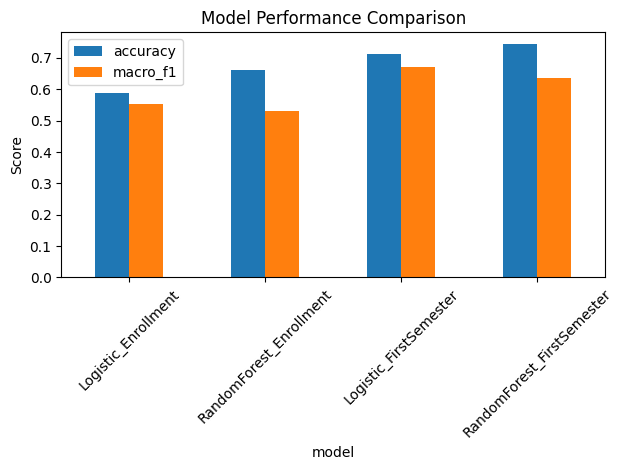

In [0]:
import matplotlib.pyplot as plt

results_df.plot(
    kind="bar",
    x="model",
    y=["accuracy", "macro_f1"]
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

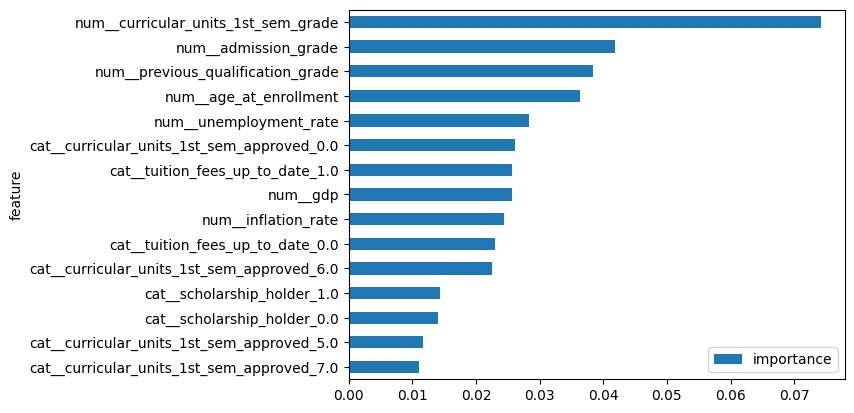

In [0]:
import pandas as pd

feature_names = rf_pipeline_X2.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipeline_X2.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(15)

importance_df.plot(kind="barh", x="feature", y="importance")
plt.gca().invert_yaxis()
plt.show()

INFO:py4j.clientserver:Received command c on object id p0


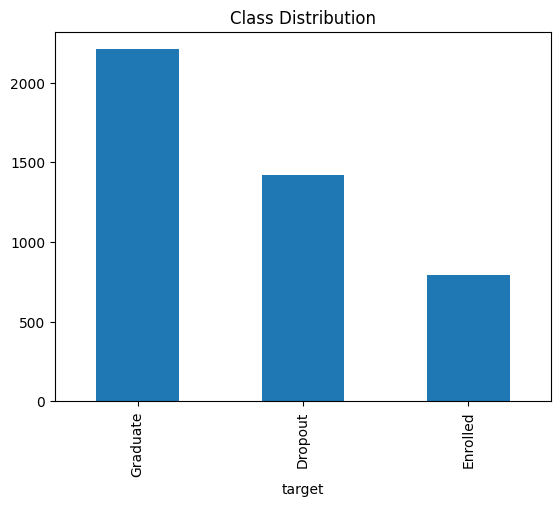

In [0]:
df["target"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.show()

### 🚀 Production Model Inference

To simulate a production workflow, we load the best model from the MLflow Model Registry using the Champion alias.

In [0]:
import mlflow
# List of columns that should be integers in your model schema
int_cols = [
    'marital_status', 'application_mode', 'application_order', 'course',
    'daytime_evening_attendance', 'previous_qualification', 'nacionality',
    'mothers_qualification', 'fathers_qualification', 'mothers_occupation',
    'fathers_occupation', 'displaced', 'educational_special_needs', 'debtor',
    'tuition_fees_up_to_date', 'gender', 'scholarship_holder', 'age_at_enrollment',
    'international', 'curricular_units_1st_sem_credited', 'curricular_units_1st_sem_enrolled',
    'curricular_units_1st_sem_evaluations', 'curricular_units_1st_sem_approved',
    'curricular_units_1st_sem_without_evaluations'
]

# Cast the columns to int
for col in int_cols:
    production_df[col] = production_df[col].astype("int64")
# Load the best model (Champion)
model = mlflow.pyfunc.load_model(
    "models:/StudentDropout_Logistic_FirstSemester@Champion"
)

# Generate predictions
preds = model.predict(X2_test)

# Attach predictions to dataset
production_df = X2_test.copy()
production_df["prediction"] = preds

production_df.head()

,marital_status,application_mode,application_order,course,daytime_evening_attendance,previous_qualification,previous_qualification_grade,nacionality,mothers_qualification,fathers_qualification,mothers_occupation,fathers_occupation,admission_grade,displaced,educational_special_needs,debtor,tuition_fees_up_to_date,gender,scholarship_holder,age_at_enrollment,international,curricular_units_1st_sem_credited,curricular_units_1st_sem_enrolled,curricular_units_1st_sem_evaluations,curricular_units_1st_sem_approved,curricular_units_1st_sem_grade,curricular_units_1st_sem_without_evaluations,unemployment_rate,inflation_rate,gdp,prediction
1932,1.0,17.0,1.0,9670.0,1.0,1.0,120.0,1.0,38.0,38.0,5.0,7.0,115.1,1.0,0.0,0.0,1.0,0.0,0.0,19.0,0.0,0.0,6.0,7.0,6.0,14.571429,0.0,12.4,0.5,1.79,2
2517,1.0,17.0,1.0,9070.0,1.0,1.0,137.0,1.0,1.0,1.0,1.0,5.0,131.8,0.0,0.0,0.0,1.0,0.0,1.0,22.0,0.0,0.0,6.0,7.0,6.0,12.166667,0.0,9.4,-0.8,-3.12,2
496,1.0,1.0,1.0,9130.0,1.0,1.0,117.0,1.0,1.0,1.0,9.0,9.0,109.3,1.0,0.0,0.0,1.0,0.0,0.0,20.0,0.0,0.0,5.0,10.0,4.0,12.500000,0.0,12.7,3.7,-1.70,1
262,2.0,7.0,1.0,8014.0,0.0,3.0,110.0,1.0,37.0,37.0,9.0,9.0,110.0,0.0,0.0,0.0,1.0,0.0,0.0,39.0,0.0,9.0,13.0,19.0,12.0,13.416667,0.0,16.2,0.3,-0.92,2
3415,1.0,17.0,1.0,9003.0,1.0,1.0,125.0,1.0,3.0,3.0,2.0,2.0,100.0,0.0,0.0,0.0,1.0,1.0,0.0,27.0,0.0,16.0,18.0,19.0,18.0,12.222222,0.0,15.5,2.8,-4.06,2


In [0]:
spark.createDataFrame(production_df).write \
    .format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("workspace.default.student_dropout_predictions")

INFO:py4j.clientserver:Received command c on object id p0


#### 💾 Persisting Predictions

Predictions are stored in a Delta table to simulate how model outputs would be consumed in a production data pipeline.